# Predict one new node from a tree

**Small tree + metadata → structured text → tiny decoder → parent and label**

This notebook is a complete, single-seed proof of concept on synthetic ancestry histories. It uses 1,000 histories, 12,000 prefix/next-addition pairs, and a two-layer transformer trained from scratch. Labels L0–L3 have no biological sequence mapping.

Run the cells in order. Select a GPU runtime for training; CUDA, Apple MPS, and CPU are supported. The best checkpoint and results are written to **artifacts/tree_next_node/**. Rerunning training replaces those outputs.

The [MacLean et al. preprint](https://www.biorxiv.org/content/10.64898/2026.07.06.736753v1) motivates interpreting observed transitions separately from fitness. Here, probabilities describe the toy growth process; this is not a reproduction of the paper or a biological forecast.


In [1]:
# If needed in a fresh notebook runtime, uncomment and run:
# %pip install "torch>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4"

import json
import math
import platform
import random
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from IPython.display import Markdown, display

@dataclass(frozen=True)
class Config:
    seed: int = 42
    n_histories: int = 1000
    nodes_per_tree: int = 16
    min_prefix: int = 4
    inherit_probability: float = 0.8
    n_layers: int = 2
    d_model: int = 128
    n_heads: int = 4
    d_ff: int = 512
    context_length: int = 256
    dropout: float = 0.1
    learning_rate: float = 3e-4
    batch_size: int = 64
    weight_decay: float = 0.01
    grad_clip: float = 1.0
    max_epochs: int = 20
    patience: int = 3
    device: str = "auto"  # "cuda", "mps", or "cpu" to override
    output_dir: str = "artifacts/tree_next_node"

cfg = Config()
assert cfg.n_histories >= 20  # At least 16 training histories for the tiny check.
assert 1 <= cfg.min_prefix < cfg.nodes_per_tree
assert cfg.d_model % cfg.n_heads == 0
assert 0 < cfg.inherit_probability < 1

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

def choose_device(requested):
    if requested != "auto":
        if requested not in {"cpu", "cuda", "mps"}:
            raise ValueError("device must be auto, cpu, cuda, or mps")
        if requested == "cuda" and not torch.cuda.is_available():
            raise RuntimeError("CUDA is unavailable; choose auto or cpu.")
        if requested == "mps" and not torch.backends.mps.is_available():
            raise RuntimeError("MPS is unavailable; choose auto or cpu.")
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

seed_everything(cfg.seed)
device = choose_device(cfg.device)
torch.set_num_threads(min(4, torch.get_num_threads()))
OUT = Path(cfg.output_dir)
OUT.mkdir(parents=True, exist_ok=True)

def save_json(filename, value):
    (OUT / filename).write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")

environment = {
    "python": platform.python_version(),
    "torch": str(torch.__version__),
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "device": str(device),
    "platform": platform.platform(),
}
print(f"Device: {device} | PyTorch: {torch.__version__}")
print(f"Outputs: {OUT.resolve()}")
print("Fixed seed; results may differ slightly across hardware and library versions.")


Matplotlib is building the font cache; this may take a moment.


Device: mps | PyTorch: 2.14.0
Outputs: /Users/pratik/Documents/work/money-maker/artifacts/tree_next_node
Fixed seed; results may differ slightly across hardware and library versions.


## 1. Generate histories, then split them

Each step adds one child to an existing node. A parent's sampling weight is **1 + its current number of children**. The child copies its parent's abstract label with probability 0.8; otherwise it receives one of the other three labels uniformly.

Node IDs and creation steps are chronological integers. We split **whole histories** 80/10/10 before making prefixes. The next node is a sampled outcome, not a uniquely determined answer.


In [2]:
@dataclass(frozen=True)
class Node:
    id: int
    parent_id: int | None
    step: int
    label: int

def validate_nodes(nodes):
    if not nodes or len(nodes) > cfg.nodes_per_tree:
        raise ValueError(f"Expected 1–{cfg.nodes_per_tree} chronological nodes.")
    for i, node in enumerate(nodes):
        if not isinstance(node, Node):
            raise TypeError("Each node must be a Node instance.")
        values = [node.id, node.step, node.label]
        if node.parent_id is not None:
            values.append(node.parent_id)
        if any(type(value) is not int for value in values):
            raise ValueError("Node fields must be integers; only the root parent may be None.")
        if node.id != i or node.step != i or not 0 <= node.label < 4:
            raise ValueError("IDs and steps must be 0..n-1; labels must be 0..3.")
        if i == 0:
            if node.parent_id is not None:
                raise ValueError("The root's parent must be None.")
        elif node.parent_id is None or not 0 <= node.parent_id < i:
            raise ValueError("Each non-root parent must precede its child.")

def simulator_parent_probs(nodes):
    counts = np.zeros(len(nodes), dtype=np.float64)
    for node in nodes[1:]:
        counts[node.parent_id] += 1
    weights = counts + 1.0
    return weights / weights.sum()

def simulator_label_probs(parent_label):
    result = np.full(4, (1.0 - cfg.inherit_probability) / 3)
    result[parent_label] = cfg.inherit_probability
    return result

def generate_history(rng):
    nodes = [Node(0, None, 0, int(rng.integers(4)))]
    for step in range(1, cfg.nodes_per_tree):
        parent = int(rng.choice(step, p=simulator_parent_probs(nodes)))
        label = int(rng.choice(4, p=simulator_label_probs(nodes[parent].label)))
        nodes.append(Node(step, parent, step, label))
    return tuple(nodes)

# Independent RNG streams prevent split assignment from depending on tree contents.
data_rng = np.random.default_rng(np.random.SeedSequence([cfg.seed, 0]))
split_rng = np.random.default_rng(np.random.SeedSequence([cfg.seed, 1]))
histories = [generate_history(data_rng) for _ in range(cfg.n_histories)]
order = split_rng.permutation(cfg.n_histories)
train_end = int(0.8 * cfg.n_histories)
valid_end = int(0.9 * cfg.n_histories)
split_ids = {
    "train": order[:train_end].tolist(),
    "validation": order[train_end:valid_end].tolist(),
    "test": order[valid_end:].tolist(),
}

def serialize_tree(nodes):
    """Return chronological text, including a NEXT PARENT prompt."""
    validate_nodes(nodes)
    lines = ["TREE"]
    for node in nodes:
        parent = "ROOT" if node.parent_id is None else f"N{node.parent_id}"
        lines.append(
            f"NODE N{node.id} PARENT {parent} STEP T{node.step} "
            f"LABEL L{node.label} ENDNODE"
        )
    return "\n".join(lines + ["ENDTREE", "NEXT PARENT"])

def parse_tree(text):
    """Parse our fixed record format for round-trip checks."""
    tokens = text.split()
    if tokens[:1] != ["TREE"] or tokens[-3:] != ["ENDTREE", "NEXT", "PARENT"]:
        raise ValueError("Invalid tree boundaries.")
    body = tokens[1:-3]
    if len(body) % 9:
        raise ValueError("Each node must contain nine tokens.")
    nodes = []
    for start in range(0, len(body), 9):
        record = body[start:start + 9]
        if record[::2] != ["NODE", "PARENT", "STEP", "LABEL", "ENDNODE"]:
            raise ValueError("Invalid node markers.")
        if not (record[1].startswith("N") and record[5].startswith("T")
                and record[7].startswith("L")):
            raise ValueError("Invalid ID, step, or label token.")
        parent_token = record[3]
        if parent_token != "ROOT" and not parent_token.startswith("N"):
            raise ValueError("Invalid parent token.")
        parent = None if parent_token == "ROOT" else int(parent_token[1:])
        nodes.append(Node(int(record[1][1:]), parent,
                          int(record[5][1:]), int(record[7][1:])))
    validate_nodes(nodes)
    return tuple(nodes)

vocabulary = (
    ["PAD", "TREE", "NODE", "PARENT", "ROOT", "STEP", "LABEL",
     "ENDNODE", "ENDTREE", "NEXT", "EOS"]
    + [f"N{i}" for i in range(cfg.nodes_per_tree)]
    + [f"T{i}" for i in range(cfg.nodes_per_tree)]
    + [f"L{i}" for i in range(4)]
)
token_to_id = {token: i for i, token in enumerate(vocabulary)}
PAD_ID = token_to_id["PAD"]
NODE_IDS = [token_to_id[f"N{i}"] for i in range(cfg.nodes_per_tree)]
LABEL_IDS = [token_to_id[f"L{i}"] for i in range(4)]

def encode(text):
    return [token_to_id[token] for token in text.split()]

def make_examples(ids):
    examples = []
    for history_id in ids:
        history = histories[history_id]
        for size in range(cfg.min_prefix, cfg.nodes_per_tree):
            nodes, target = history[:size], history[size]
            examples.append({
                "history_id": history_id,
                "nodes": nodes,
                "prefix_ids": encode(serialize_tree(nodes)),
                "parent": target.parent_id,
                "label": target.label,
            })
    return examples

examples = {name: make_examples(ids) for name, ids in split_ids.items()}
for name, rows in examples.items():
    print(f"{name:10s}: {len(split_ids[name]):4d} histories, {len(rows):5d} examples")
example = examples["train"][0]
print("\nInput:\n" + serialize_tree(example["nodes"]))
print(f'\nTarget:\nN{example["parent"]} LABEL L{example["label"]} EOS')


train     :  800 histories,  9600 examples
validation:  100 histories,  1200 examples
test      :  100 histories,  1200 examples

Input:
TREE
NODE N0 PARENT ROOT STEP T0 LABEL L0 ENDNODE
NODE N1 PARENT N0 STEP T1 LABEL L0 ENDNODE
NODE N2 PARENT N1 STEP T2 LABEL L0 ENDNODE
NODE N3 PARENT N2 STEP T3 LABEL L0 ENDNODE
ENDTREE
NEXT PARENT

Target:
N3 LABEL L2 EOS


## 2. Check the data and prepare batches

The input prefix contains only existing nodes. During training, the true parent is appended **after** the parent-prediction position so the label can be learned conditionally. The target label is never inserted into the input.

Right padding follows all useful tokens. Causal attention therefore prevents it from affecting either prediction. Only parent and label choices contribute to loss; format markers are supplied automatically.


In [3]:
def collate(rows):
    sequences, parent_positions, label_positions = [], [], []
    for row in rows:
        prefix = row["prefix_ids"]
        sequences.append(prefix + [NODE_IDS[row["parent"]], token_to_id["LABEL"]])
        parent_positions.append(len(prefix) - 1)  # NEXT PARENT -> predict parent
        label_positions.append(len(prefix) + 1)  # parent LABEL -> predict label
    longest = max(map(len, sequences))
    if longest > cfg.context_length:
        raise ValueError("Example exceeds context_length; no silent truncation.")
    input_ids = torch.full((len(rows), longest), PAD_ID, dtype=torch.long)
    for i, sequence in enumerate(sequences):
        input_ids[i, :len(sequence)] = torch.tensor(sequence)
    return {
        "input_ids": input_ids,
        "parent_position": torch.tensor(parent_positions),
        "label_position": torch.tensor(label_positions),
        "size": torch.tensor([len(row["nodes"]) for row in rows]),
        "parent": torch.tensor([row["parent"] for row in rows]),
        "label": torch.tensor([row["label"] for row in rows]),
    }

def on_device(batch, destination=device):
    return {key: value.to(destination) for key, value in batch.items()}

def make_loader(rows, shuffle=False):
    return DataLoader(
        rows, batch_size=cfg.batch_size, shuffle=shuffle, collate_fn=collate,
        num_workers=0, generator=torch.Generator().manual_seed(cfg.seed),
    )

def check_data():
    id_sets = [set(ids) for ids in split_ids.values()]
    assert all(not id_sets[i] & id_sets[j]
               for i in range(3) for j in range(i + 1, 3))
    assert set.union(*id_sets) == set(range(cfg.n_histories))
    assert sum(map(len, examples.values())) == (
        cfg.n_histories * (cfg.nodes_per_tree - cfg.min_prefix)
    )
    for name, rows in examples.items():
        for row in rows:
            size = len(row["nodes"])
            history = histories[row["history_id"]]
            assert row["history_id"] in set(split_ids[name])
            assert row["nodes"] == history[:size]
            assert parse_tree(serialize_tree(row["nodes"])) == row["nodes"]
            assert row["parent"] == history[size].parent_id < size
            assert row["label"] == history[size].label
            assert row["prefix_ids"] == encode(serialize_tree(history[:size]))
            assert token_to_id[f"N{size}"] not in row["prefix_ids"]
            assert len(row["prefix_ids"]) + 2 <= cfg.context_length
    # Mutating the unseen future must leave the input unchanged.
    history = list(histories[split_ids["train"][0]])
    size = cfg.min_prefix
    before = serialize_tree(history[:size])
    history[size] = replace(history[size], label=(history[size].label + 1) % 4)
    assert serialize_tree(history[:size]) == before
    # Targets are outside the prompt; padding and mixed lengths are exercised.
    batch = collate([examples["train"][0], examples["train"][-1]])
    for i, row in enumerate([examples["train"][0], examples["train"][-1]]):
        p = len(row["prefix_ids"])
        assert batch["input_ids"][i, :p].tolist() == row["prefix_ids"]
        assert batch["input_ids"][i, p].item() == NODE_IDS[row["parent"]]
        assert batch["input_ids"][i, p + 1].item() == token_to_id["LABEL"]
    print("PASS: round trips, temporal inputs, split isolation, targets, and context limits.")

check_data()
train_loader = make_loader(examples["train"], shuffle=True)
validation_loader = make_loader(examples["validation"])
test_loader = make_loader(examples["test"])
save_json("config.json", asdict(cfg))
save_json("vocabulary.json", {"tokens": vocabulary, "token_to_id": token_to_id})
save_json("split_ids.json", split_ids)
save_json("environment.json", environment)


PASS: round trips, temporal inputs, split isolation, targets, and context limits.


## 3. Tiny decoder

Two pre-normalized transformer blocks, four attention heads, width 128, and feed-forward width 512. Attention is causal; there is no encoder or cross-attention. Token and position embeddings are learned from scratch.

The shared vocabulary head supplies both choices. Parent logits are restricted to IDs present in the prefix; label logits are restricted to L0–L3. These same distributions are used for training, likelihood evaluation, and generation.


In [4]:
class DecoderBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_heads
        self.head_width = config.d_model // config.n_heads
        self.dropout_p = config.dropout
        self.norm1 = nn.LayerNorm(config.d_model)
        self.qkv = nn.Linear(config.d_model, 3 * config.d_model)
        self.projection = nn.Linear(config.d_model, config.d_model)
        self.norm2 = nn.LayerNorm(config.d_model)
        self.mlp = nn.Sequential(
            nn.Linear(config.d_model, config.d_ff), nn.GELU(),
            nn.Linear(config.d_ff, config.d_model), nn.Dropout(config.dropout),
        )
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        batch, length, width = x.shape
        qkv = self.qkv(self.norm1(x)).reshape(
            batch, length, 3, self.n_heads, self.head_width
        ).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attention = F.scaled_dot_product_attention(
            q, k, v, is_causal=True,
            dropout_p=self.dropout_p if self.training else 0.0,
        )
        attention = attention.transpose(1, 2).contiguous().reshape(batch, length, width)
        x = x + self.dropout(self.projection(attention))
        return x + self.mlp(self.norm2(x))

class TinyDecoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.token_embedding = nn.Embedding(len(vocabulary), config.d_model)
        self.position_embedding = nn.Embedding(config.context_length, config.d_model)
        self.dropout = nn.Dropout(config.dropout)
        self.blocks = nn.Sequential(
            *[DecoderBlock(config) for _ in range(config.n_layers)]
        )
        self.norm = nn.LayerNorm(config.d_model)
        self.head = nn.Linear(config.d_model, len(vocabulary), bias=False)

    def forward(self, input_ids):
        if input_ids.shape[1] > self.config.context_length:
            raise ValueError("Sequence is longer than the model context.")
        positions = torch.arange(input_ids.shape[1], device=input_ids.device)
        x = self.token_embedding(input_ids) + self.position_embedding(positions)
        return self.head(self.norm(self.blocks(self.dropout(x))))

def choice_logits(net, batch):
    logits = net(batch["input_ids"])
    indices = torch.arange(logits.shape[0], device=logits.device)
    parent_logits = logits[indices, batch["parent_position"]][:, NODE_IDS]
    invalid = torch.arange(len(NODE_IDS), device=logits.device)[None, :] >= batch["size"][:, None]
    parent_logits = parent_logits.masked_fill(invalid, float("-inf"))
    label_logits = logits[indices, batch["label_position"]][:, LABEL_IDS]
    return parent_logits, label_logits

def joint_nll(parent_logits, label_logits, batch):
    return (
        F.cross_entropy(parent_logits, batch["parent"], reduction="none")
        + F.cross_entropy(label_logits, batch["label"], reduction="none")
    )

@torch.no_grad()
def greedy_batch(net, batch, parent_logits=None):
    """Decode label using the predicted parent, never the observed parent."""
    net.eval()
    if parent_logits is None:
        parent_logits, _ = choice_logits(net, batch)
    parents = parent_logits.argmax(dim=-1)
    generated = dict(batch)
    generated["input_ids"] = batch["input_ids"].clone()
    indices = torch.arange(len(parents), device=parents.device)
    node_token_ids = torch.tensor(NODE_IDS, device=parents.device)
    generated["input_ids"][indices, batch["parent_position"] + 1] = node_token_ids[parents]
    _, label_logits = choice_logits(net, generated)
    labels = label_logits.argmax(dim=-1)
    log_probability = (
        parent_logits.log_softmax(-1)[indices, parents]
        + label_logits.log_softmax(-1)[indices, labels]
    )
    return parents, labels, log_probability.exp()

@torch.no_grad()
def evaluate_model(net, loader, include_accuracy=True):
    net.eval()
    total, nll_sum, parent_hits, label_hits, joint_hits = 0, 0.0, 0, 0, 0
    for raw_batch in loader:
        batch = on_device(raw_batch, next(net.parameters()).device)
        parent_logits, label_logits = choice_logits(net, batch)
        nll_sum += joint_nll(parent_logits, label_logits, batch).sum().item()
        total += len(batch["parent"])
        if include_accuracy:
            parents, labels, probabilities = greedy_batch(net, batch, parent_logits)
            assert bool(((parents >= 0) & (parents < batch["size"])).all())
            assert bool(((labels >= 0) & (labels < 4)).all())
            assert bool((torch.isfinite(probabilities) & (probabilities > 0)
                         & (probabilities <= 1)).all())
            parent_ok = parents == batch["parent"]
            label_ok = labels == batch["label"]
            parent_hits += parent_ok.sum().item()
            label_hits += label_ok.sum().item()
            joint_hits += (parent_ok & label_ok).sum().item()
    result = {"joint_nll": nll_sum / total, "n_examples": total}
    if include_accuracy:
        result.update(
            parent_accuracy=parent_hits / total,
            label_accuracy=label_hits / total,
            joint_accuracy=joint_hits / total,
            valid_prediction_rate=1.0,
        )
    return result

seed_everything(cfg.seed)
model = TinyDecoder(cfg).to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"{parameter_count:,} parameters | vocabulary {len(vocabulary)} | context {cfg.context_length}")


441,600 parameters | vocabulary 47 | context 256


## 4. Verify causality and overfit a tiny batch

Before the real run, check that changing a future target parent cannot change earlier parent logits, that right padding leaves predictions unchanged, and that constrained likelihood matches a hand-computed uniform distribution.

A disposable model with dropout disabled must memorize 16 distinct training examples. This is a debugging check, not the experiment. The main model is freshly initialized with seed 42 afterward.


In [5]:
def check_model_math(net):
    net.eval()
    raw = collate([examples["train"][0], examples["train"][-1]])
    batch = on_device(raw, next(net.parameters()).device)
    with torch.no_grad():
        p1, _ = choice_logits(net, batch)
        changed = {key: value.clone() for key, value in batch.items()}
        indices = torch.arange(len(batch["parent"]), device=batch["parent"].device)
        changed_parents = (batch["parent"] + 1) % batch["size"]
        node_token_ids = torch.tensor(NODE_IDS, device=indices.device)
        changed["input_ids"][indices, batch["parent_position"] + 1] = node_token_ids[changed_parents]
        p2, _ = choice_logits(net, changed)
        torch.testing.assert_close(p1, p2, rtol=2e-5, atol=2e-5)
        # Even the generated labels must be independent of teacher-forced parents.
        parents1, labels1, probs1 = greedy_batch(net, batch, p1)
        parents2, labels2, probs2 = greedy_batch(net, changed, p2)
        assert torch.equal(parents1, parents2) and torch.equal(labels1, labels2)
        torch.testing.assert_close(probs1, probs2, rtol=2e-5, atol=2e-5)
        solo = on_device(collate([examples["train"][0]]), indices.device)
        p_solo, l_solo = choice_logits(net, solo)
        p_batch, l_batch = choice_logits(net, batch)
        torch.testing.assert_close(p_solo[0], p_batch[0], rtol=2e-5, atol=2e-5)
        torch.testing.assert_close(l_solo[0], l_batch[0], rtol=2e-5, atol=2e-5)
        uniform_parent = torch.zeros_like(p1).masked_fill(torch.isinf(p1), float("-inf"))
        uniform_label = torch.zeros((len(indices), 4), device=indices.device)
        actual = joint_nll(uniform_parent, uniform_label, batch)
        expected = batch["size"].float().log() + math.log(4)
        torch.testing.assert_close(actual, expected)
    print("PASS: causal isolation, generated-parent conditioning, padding, and likelihood math.")

def tiny_overfit_check():
    seed_everything(cfg.seed + 11)
    tiny = TinyDecoder(replace(cfg, dropout=0.0)).to(device)
    # One long prefix per history; deduplicate prompts to avoid conflicting draws.
    selected, seen = [], set()
    for row in examples["train"]:
        key = tuple(row["prefix_ids"])
        if len(row["nodes"]) == cfg.nodes_per_tree - 1 and key not in seen:
            selected.append(row)
            seen.add(key)
        if len(selected) == 16:
            break
    if len(selected) < 16:
        raise ValueError("Tiny overfit check requires at least 16 distinct training histories.")
    batch = on_device(collate(selected))
    optimizer = torch.optim.AdamW(tiny.parameters(), lr=1e-3, weight_decay=0)
    initial = evaluate_model(tiny, make_loader(selected))["joint_nll"]
    result = None
    for step in range(1, 301):
        tiny.train()
        optimizer.zero_grad(set_to_none=True)
        p, l = choice_logits(tiny, batch)
        loss = joint_nll(p, l, batch).mean()
        loss.backward()
        nn.utils.clip_grad_norm_(tiny.parameters(), cfg.grad_clip)
        optimizer.step()
        if step % 25 == 0:
            result = evaluate_model(tiny, make_loader(selected))
            print(f"Tiny check {step:3d}/300 | NLL {result['joint_nll']:.4f} | "
                  f"joint accuracy {result['joint_accuracy']:.1%}", flush=True)
            if result["joint_nll"] < 0.05 and result["joint_accuracy"] == 1.0:
                break
    assert result["joint_nll"] < 0.05 and result["joint_accuracy"] == 1.0, (
        "Tiny-batch overfit failed; fix training before interpreting the main experiment."
    )
    seed_everything(cfg.seed)
    return {"passed": True, "steps": step, "initial_joint_nll": initial, **result}

check_model_math(model)
tiny_check = tiny_overfit_check()
save_json("checks.json", {"data_checks": True, "model_math_checks": True,
                         "tiny_overfit": tiny_check})


PASS: causal isolation, generated-parent conditioning, padding, and likelihood math.


Tiny check  25/300 | NLL 0.9105 | joint accuracy 81.2%


Tiny check  50/300 | NLL 0.0150 | joint accuracy 100.0%


## 5. Train once; select using validation only

AdamW, learning rate 0.0003, batch size 64, weight decay 0.01, gradient clipping 1.0, and at most 20 epochs. Stop after three epochs without improved validation joint negative log-likelihood.

The checkpoint is saved on each validation improvement. No test examples or test metrics enter training or checkpoint selection.


In [6]:
def fit():
    seed_everything(cfg.seed)
    net = TinyDecoder(cfg).to(device)
    optimizer = torch.optim.AdamW(
        net.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay
    )
    loader = make_loader(examples["train"], shuffle=True)
    history, best_nll, bad_epochs = [], float("inf"), 0
    started = time.perf_counter()
    for epoch in range(1, cfg.max_epochs + 1):
        epoch_started = time.perf_counter()
        net.train()
        loss_sum, count = 0.0, 0
        for raw_batch in loader:
            batch = on_device(raw_batch)
            optimizer.zero_grad(set_to_none=True)
            p, l = choice_logits(net, batch)
            loss = joint_nll(p, l, batch).mean()
            if not bool(torch.isfinite(loss)):
                raise FloatingPointError("Non-finite training loss.")
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), cfg.grad_clip)
            optimizer.step()
            loss_sum += loss.item() * len(batch["parent"])
            count += len(batch["parent"])
        validation = evaluate_model(net, validation_loader, include_accuracy=False)
        val_nll = validation["joint_nll"]
        if not math.isfinite(val_nll):
            raise FloatingPointError("Non-finite validation loss.")
        improved = val_nll < best_nll
        if improved:
            best_nll, bad_epochs = val_nll, 0
            torch.save({
                "state_dict": {key: value.detach().cpu().clone()
                               for key, value in net.state_dict().items()},
                "config": asdict(cfg),
                "vocabulary": vocabulary,
                "epoch": epoch,
                "validation_joint_nll": val_nll,
            }, OUT / "checkpoint.pt")
        else:
            bad_epochs += 1
        record = {
            "epoch": epoch, "train_joint_nll": loss_sum / count,
            "validation_joint_nll": val_nll,
            "seconds": time.perf_counter() - epoch_started,
            "checkpoint_saved": improved,
        }
        history.append(record)
        save_json("training_history.json", history)
        print(
            f"Epoch {epoch:02d}/{cfg.max_epochs} | train {record['train_joint_nll']:.4f} | "
            f"validation {val_nll:.4f} | {record['seconds']:.1f}s"
            + (" | best" if improved else ""), flush=True,
        )
        if bad_epochs >= cfg.patience:
            print(f"Early stopping after {cfg.patience} epochs without improvement.")
            break
    checkpoint = torch.load(OUT / "checkpoint.pt", map_location="cpu", weights_only=True)
    net.load_state_dict(checkpoint["state_dict"])
    net.eval()
    details = {
        "best_epoch": checkpoint["epoch"],
        "best_validation_joint_nll": checkpoint["validation_joint_nll"],
        "epochs_run": len(history),
        "total_seconds": time.perf_counter() - started,
        "parameter_count": sum(parameter.numel() for parameter in net.parameters()),
    }
    return net, history, details

model, training_history, training_details = fit()
print(f"\nRestored epoch {training_details['best_epoch']} for final evaluation.")


Epoch 01/20 | train 3.1286 | validation 2.9848 | 4.9s | best


Epoch 02/20 | train 2.9669 | validation 2.9448 | 4.1s | best


Epoch 03/20 | train 2.9326 | validation 2.9288 | 4.2s | best


Epoch 04/20 | train 2.9146 | validation 2.9300 | 4.2s


Epoch 05/20 | train 2.9079 | validation 2.9079 | 4.2s | best


Epoch 06/20 | train 2.8977 | validation 2.9134 | 4.2s


Epoch 07/20 | train 2.8854 | validation 2.9258 | 4.1s


Epoch 08/20 | train 2.8867 | validation 2.9343 | 4.1s


Early stopping after 3 epochs without improvement.

Restored epoch 5 for final evaluation.


## 6. Compare on untouched test histories

- **Uniform:** choose among existing parents and the four labels uniformly.
- **Frequency:** parent counts conditioned on prefix size, and overall target-label counts, fitted only on training examples. Add-one smoothing avoids zero probabilities.
- **Simulator reference:** the true conditional probabilities used to generate the data.

All methods use greedy parent selection, followed by a label prediction conditional on that selected parent when applicable. Ties choose the lowest ID. Likelihood instead evaluates the observed pair as **P(observed parent | tree) × P(observed label | tree, observed parent)**.

Lower joint negative log-likelihood is better. Success requires beating **both** naive baselines on this measure. Test prefixes are correlated within 100 independent histories; this one-seed result is not a statistical significance claim.


In [7]:
def fit_frequency_baseline(training_rows):
    parent_counts = {
        size: np.ones(size, dtype=np.float64)
        for size in range(cfg.min_prefix, cfg.nodes_per_tree)
    }
    label_counts = np.ones(4, dtype=np.float64)
    for row in training_rows:
        parent_counts[len(row["nodes"])][row["parent"]] += 1
        label_counts[row["label"]] += 1
    return {
        "parent_probs": {size: counts / counts.sum()
                         for size, counts in parent_counts.items()},
        "label_probs": label_counts / label_counts.sum(),
        "smoothing": 1.0,
    }

frequency = fit_frequency_baseline(examples["train"])

def baseline_distribution(name, nodes):
    size = len(nodes)
    if name == "uniform":
        parent_probs = np.full(size, 1 / size)
        label_given_parent = np.full((size, 4), 1 / 4)
    elif name == "frequency":
        parent_probs = frequency["parent_probs"][size]
        label_given_parent = np.tile(frequency["label_probs"], (size, 1))
    elif name == "simulator":
        parent_probs = simulator_parent_probs(nodes)
        label_given_parent = np.stack([
            simulator_label_probs(node.label) for node in nodes
        ])
    else:
        raise ValueError(f"Unknown baseline: {name}")
    return parent_probs, label_given_parent

def evaluate_baseline(name, rows):
    total_nll, parent_hits, label_hits, joint_hits = 0.0, 0, 0, 0
    for row in rows:
        p, l = baseline_distribution(name, row["nodes"])
        assert np.isclose(p.sum(), 1) and np.allclose(l.sum(axis=1), 1)
        parent = int(p.argmax())
        label = int(l[parent].argmax())
        total_nll -= math.log(p[row["parent"]]) + math.log(l[row["parent"], row["label"]])
        parent_ok, label_ok = parent == row["parent"], label == row["label"]
        parent_hits += parent_ok
        label_hits += label_ok
        joint_hits += parent_ok and label_ok
    total = len(rows)
    return {
        "joint_nll": total_nll / total,
        "parent_accuracy": parent_hits / total,
        "label_accuracy": label_hits / total,
        "joint_accuracy": joint_hits / total,
        "valid_prediction_rate": 1.0,
        "n_examples": total,
    }

results = {
    "transformer": evaluate_model(model, test_loader),
    **{name: evaluate_baseline(name, examples["test"])
       for name in ["uniform", "frequency", "simulator"]},
}
learning_demonstrated = all(
    results["transformer"]["joint_nll"] < results[name]["joint_nll"]
    for name in ["uniform", "frequency"]
)
metrics = {
    "learning_demonstrated": learning_demonstrated,
    "criterion": "test joint NLL strictly below both uniform and frequency baselines",
    "seed": cfg.seed,
    "test_histories": len(split_ids["test"]),
    "training": training_details,
    "results": results,
    "tiny_overfit": tiny_check,
    "limits": "Single seed; synthetic labels; correlated prefixes within held-out histories.",
}
save_json("metrics.json", metrics)
save_json("frequency_baseline.json", {
    "parent_probs_by_prefix_size": {
        str(size): values.tolist() for size, values in frequency["parent_probs"].items()
    },
    "label_probs": frequency["label_probs"].tolist(),
    "smoothing": frequency["smoothing"],
})

table = ["| Method | Joint NLL ↓ | Parent accuracy | Label accuracy | Both correct |",
         "|---|---:|---:|---:|---:|"]
for name, values in results.items():
    table.append(
        f"| {name} | {values['joint_nll']:.4f} | {values['parent_accuracy']:.1%} | "
        f"{values['label_accuracy']:.1%} | {values['joint_accuracy']:.1%} |"
    )
display(Markdown("\n".join(table)))
if learning_demonstrated:
    display(Markdown("**Learning demonstrated:** the transformer beats both naive baselines on held-out joint NLL."))
else:
    display(Markdown("**Learning not demonstrated by the agreed criterion.** Report this run as-is; do not tune against the test set."))
display(Markdown(
    "Accuracy uses generated parents; NLL scores the observed pair. "
    "The simulator is a probabilistic reference, not an achievable guarantee of perfect exact prediction."
))


| Method | Joint NLL ↓ | Parent accuracy | Label accuracy | Both correct |
|---|---:|---:|---:|---:|
| transformer | 2.8489 | 34.5% | 68.2% | 26.8% |
| uniform | 3.5619 | 33.1% | 22.7% | 8.3% |
| frequency | 3.3869 | 33.1% | 22.7% | 8.3% |
| simulator | 2.6320 | 35.2% | 67.4% | 28.1% |

**Learning demonstrated:** the transformer beats both naive baselines on held-out joint NLL.

Accuracy uses generated parents; NLL scores the observed pair. The simulator is a probabilistic reference, not an achievable guarantee of perfect exact prediction.

## 7. Predict and inspect one addition

The public helpers are **serialize_tree(nodes)** and **predict_next(nodes)**. Nodes are chronological Node records; labels are integers 0–3, rendered as L0–L3 in the text and diagrams.

Prediction returns the automatically assigned ID and step, an existing parent ID, a label, and the joint probability of the generated pair. It uses greedy parent-then-label decoding, not exhaustive joint search.

The displayed example is fixed in advance: the first test history at eight existing nodes (or the configured minimum if larger). It is not selected for correctness.


TREE
NODE N0 PARENT ROOT STEP T0 LABEL L3 ENDNODE
NODE N1 PARENT N0 STEP T1 LABEL L3 ENDNODE
NODE N2 PARENT N1 STEP T2 LABEL L1 ENDNODE
NODE N3 PARENT N0 STEP T3 LABEL L3 ENDNODE
NODE N4 PARENT N0 STEP T4 LABEL L3 ENDNODE
NODE N5 PARENT N0 STEP T5 LABEL L3 ENDNODE
NODE N6 PARENT N4 STEP T6 LABEL L3 ENDNODE
NODE N7 PARENT N0 STEP T7 LABEL L3 ENDNODE
ENDTREE
NEXT PARENT

Prediction: N0 LABEL L3 EOS
Actual:     N3 LABEL L3 EOS
Generated-pair probability: 0.3436


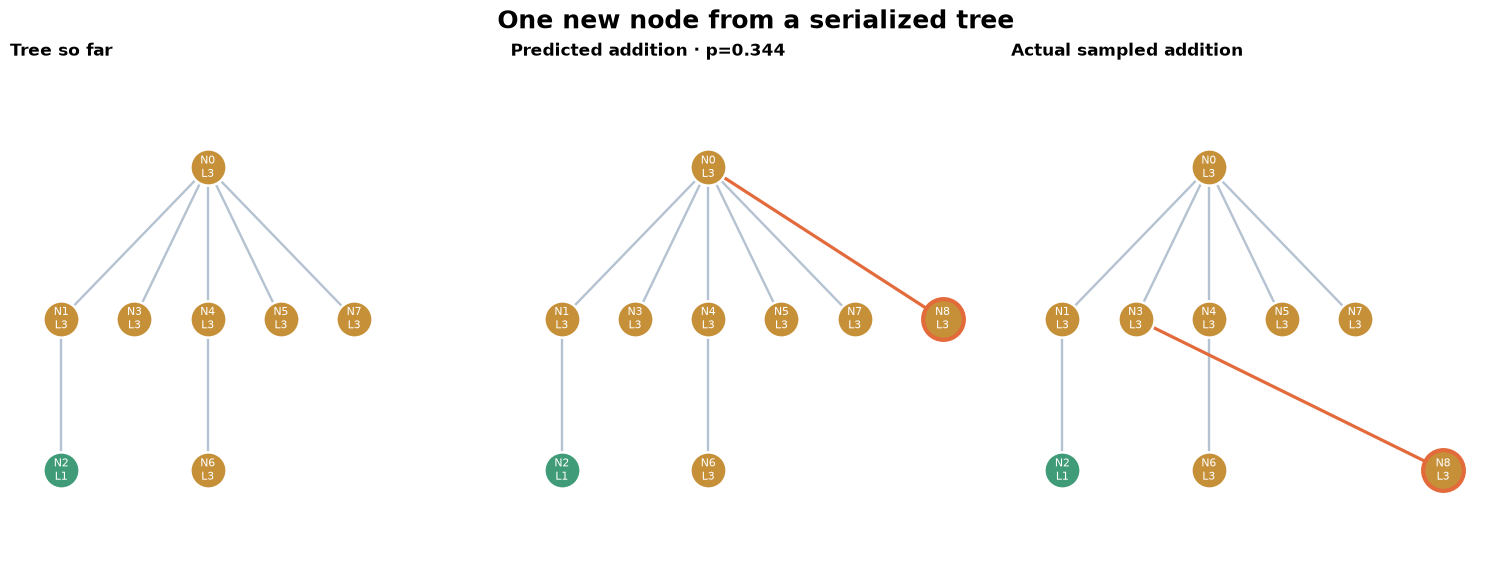

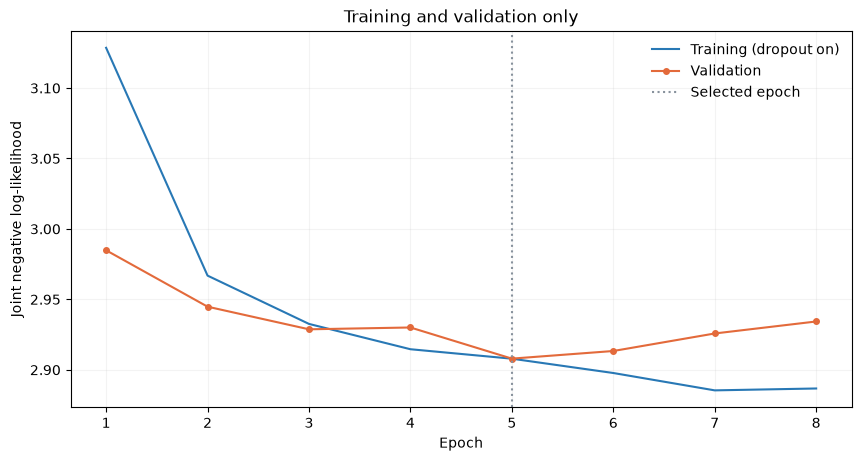

In [8]:
@torch.no_grad()
def predict_with(net, nodes):
    validate_nodes(nodes)
    if not cfg.min_prefix <= len(nodes) < cfg.nodes_per_tree:
        raise ValueError(
            f"Predict on {cfg.min_prefix}–{cfg.nodes_per_tree - 1} existing nodes; "
            "extrapolation beyond the training sizes is outside this PoC."
        )
    # The placeholder parent is replaced by the generated parent before label decoding.
    row = {"nodes": tuple(nodes), "prefix_ids": encode(serialize_tree(nodes)),
           "parent": 0, "label": 0}
    batch = on_device(collate([row]), next(net.parameters()).device)
    parents, labels, probabilities = greedy_batch(net, batch)
    return {
        "id": len(nodes), "parent_id": int(parents[0].item()),
        "step": len(nodes), "label": int(labels[0].item()),
        "joint_probability": float(probabilities[0].item()),
    }

def predict_next(nodes):
    """Predict one child with the selected model. Labels are integers 0–3."""
    return predict_with(model, nodes)

display_size = min(max(8, cfg.min_prefix), cfg.nodes_per_tree - 1)
display_example = next(row for row in examples["test"]
                       if len(row["nodes"]) == display_size)
display_nodes = display_example["nodes"]
prediction = predict_next(display_nodes)
actual = {
    "id": len(display_nodes), "parent_id": display_example["parent"],
    "step": len(display_nodes), "label": display_example["label"],
}
example_result = {
    "history_id": display_example["history_id"], "prefix_size": display_size,
    "input": [asdict(node) for node in display_nodes],
    "prediction": prediction, "actual": actual,
    "both_correct": (prediction["parent_id"] == actual["parent_id"]
                     and prediction["label"] == actual["label"]),
}
save_json("example_prediction.json", example_result)
print(serialize_tree(display_nodes))
print(f"\nPrediction: N{prediction['parent_id']} LABEL L{prediction['label']} EOS")
print(f"Actual:     N{actual['parent_id']} LABEL L{actual['label']} EOS")
print(f"Generated-pair probability: {prediction['joint_probability']:.4f}")

def tree_positions(nodes):
    children = {node.id: [] for node in nodes}
    for node in nodes[1:]:
        children[node.parent_id].append(node.id)
    positions, leaf_index = {}, [0]
    def visit(node_id, depth):
        xs = [visit(child, depth + 1) for child in children[node_id]]
        if xs:
            x = float(np.mean(xs))
        else:
            x = leaf_index[0]
            leaf_index[0] += 1
        positions[node_id] = (x, -depth)
        return x
    visit(0, 0)
    return positions

def draw_tree(ax, nodes, title, addition=None):
    points = tree_positions(nodes)
    for node in nodes[1:]:
        x0, y0 = points[node.parent_id]
        x1, y1 = points[node.id]
        ax.plot([x0, x1], [y0, y1], color="#B4C2D1", linewidth=1.7, zorder=1)
    colors = ["#2878B5", "#3F9B78", "#AD70AF", "#C69038"]
    for node in nodes:
        x, y = points[node.id]
        ax.scatter(x, y, s=680, color=colors[node.label], edgecolor="white",
                   linewidth=1.8, zorder=3)
        ax.text(x, y, f"N{node.id}\nL{node.label}", color="white",
                ha="center", va="center", fontsize=8, zorder=4)
    all_points = list(points.values())
    if addition is not None:
        parent_x, parent_y = points[addition["parent_id"]]
        # Put the new node on a right-hand rail to preserve the input layout in all panels.
        new_x = max(x for x, _ in points.values()) + 1.2
        new_y = parent_y - 1
        ax.annotate("", xy=(new_x, new_y), xytext=(parent_x, parent_y),
                    arrowprops={"arrowstyle": "->", "color": "#E36A3B", "lw": 2.3},
                    zorder=2)
        ax.scatter(new_x, new_y, s=860, color=colors[addition["label"]],
                   edgecolor="#E36A3B", linewidth=3, zorder=3)
        ax.text(new_x, new_y, f"N{addition['id']}\nL{addition['label']}",
                color="white", ha="center", va="center", fontsize=8, zorder=4)
        all_points.append((new_x, new_y))
    ax.set_title(title, loc="left", fontsize=12, fontweight="bold", pad=15)
    ax.set_xlim(-0.7, max(x for x, _ in points.values()) + 2)
    ax.set_ylim(min(y for _, y in all_points) - 0.6, 0.6)
    ax.axis("off")

plt.rcParams.update({"font.family": "DejaVu Sans", "figure.facecolor": "white"})
fig, axes = plt.subplots(1, 3, figsize=(15, 5.6), layout="constrained")
draw_tree(axes[0], display_nodes, "Tree so far")
draw_tree(axes[1], display_nodes,
          f"Predicted addition · p={prediction['joint_probability']:.3f}", prediction)
draw_tree(axes[2], display_nodes, "Actual sampled addition", actual)
bottom = min(axis.get_ylim()[0] for axis in axes)
for axis in axes:
    axis.set_ylim(bottom, 0.6)
fig.suptitle("One new node from a serialized tree", fontsize=18, fontweight="bold")
fig.savefig(OUT / "example_prediction.png", dpi=170, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 4.5), layout="constrained")
epochs = [row["epoch"] for row in training_history]
ax.plot(epochs, [row["train_joint_nll"] for row in training_history],
        label="Training (dropout on)", color="#2878B5")
ax.plot(epochs, [row["validation_joint_nll"] for row in training_history],
        label="Validation", color="#E36A3B", marker="o", markersize=4)
ax.axvline(training_details["best_epoch"], color="#88929D", linestyle=":",
           label="Selected epoch")
ax.set(xlabel="Epoch", ylabel="Joint negative log-likelihood",
       title="Training and validation only")
ax.legend(frameon=False)
ax.grid(alpha=0.15)
fig.savefig(OUT / "training_curves.png", dpi=170, bbox_inches="tight")
plt.show()


## 8. Reload the checkpoint and verify inference

The checkpoint contains tensors and basic configuration data and is loaded with weights_only=True. This round trip verifies that the saved model reproduces the selected model's prediction. It also runs a CPU forward pass and checks invalid-input handling.

For inference in a new session, run sections 1–3 after setup, define the prediction helpers from section 7, then use load_checkpoint below; skip the overfit, training, and evaluation calls. Use the same saved configuration and vocabulary. A different configuration is rejected rather than silently interpreted.

The artifacts record the original run and its limitations. A successful result demonstrates learnability of these toy transitions, not biological validity or the necessity of this particular representation.


In [9]:
def load_checkpoint(path=OUT / "checkpoint.pt", destination=None):
    destination = device if destination is None else torch.device(destination)
    checkpoint = torch.load(path, map_location="cpu", weights_only=True)
    if checkpoint["vocabulary"] != vocabulary:
        raise ValueError("Checkpoint vocabulary differs from the active vocabulary.")
    saved_config = Config(**checkpoint["config"])
    relevant = [
        "nodes_per_tree", "min_prefix", "n_layers", "d_model", "n_heads",
        "d_ff", "context_length", "dropout",
    ]
    if any(getattr(saved_config, field) != getattr(cfg, field) for field in relevant):
        raise ValueError("Run the setup with the saved configuration before loading.")
    restored = TinyDecoder(saved_config)
    restored.load_state_dict(checkpoint["state_dict"])
    return restored.to(destination).eval()

restored_model = load_checkpoint()
restored_prediction = predict_with(restored_model, display_nodes)
assert restored_prediction["parent_id"] == prediction["parent_id"]
assert restored_prediction["label"] == prediction["label"]
assert math.isclose(restored_prediction["joint_probability"],
                    prediction["joint_probability"], rel_tol=2e-5, abs_tol=2e-6)

cpu_model = load_checkpoint(destination="cpu")
cpu_prediction = predict_with(cpu_model, display_nodes)
assert 0 <= cpu_prediction["parent_id"] < len(display_nodes)
assert 0 <= cpu_prediction["label"] < 4
assert math.isfinite(cpu_prediction["joint_probability"])

invalid_inputs = [
    (),
    (Node(0, 0, 0, 0),),
    (Node(0, None, 0, 4),),
    (Node(0, None, 0, 0.5),),
    (Node(0, None, 0, True),),
    (Node(0, None, 0, 0), Node(1, 1, 1, 0)),
    histories[split_ids["test"][0]],  # already at the maximum node count
]
for invalid in invalid_inputs:
    try:
        predict_next(invalid)
    except (ValueError, TypeError):
        pass
    else:
        raise AssertionError("Invalid or unsupported input was accepted.")

checks = {
    "data_checks": True, "model_math_checks": True,
    "tiny_overfit": tiny_check, "checkpoint_round_trip": True,
    "cpu_inference": True, "invalid_input_checks": True,
    "valid_test_predictions": results["transformer"]["valid_prediction_rate"] == 1,
}
save_json("checks.json", checks)
print("PASS: checkpoint reload, CPU inference, invalid inputs, and all test predictions.")
print("\nSaved outputs:")
for path in sorted(OUT.iterdir()):
    if path.is_file():
        print(f"  {path.name} ({path.stat().st_size:,} bytes)")
del restored_model, cpu_model


PASS: checkpoint reload, CPU inference, invalid inputs, and all test predictions.

Saved outputs:
  checkpoint.pt (1,776,821 bytes)
  checks.json (461 bytes)
  config.json (414 bytes)
  environment.json (156 bytes)
  example_prediction.json (974 bytes)
  example_prediction.png (123,601 bytes)
  frequency_baseline.json (3,473 bytes)
  metrics.json (1,765 bytes)
  split_ids.json (8,948 bytes)
  training_curves.png (73,199 bytes)
  training_history.json (1,427 bytes)
  vocabulary.json (1,244 bytes)
